In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import glob
import cv2
import tensorflow as tf
import math
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt
import numpy.ma as ma
from sklearn.metrics import mean_squared_error

In [ ]:
#Mask the result
def mask_result(r,totalmask):
  result_mask=ma.masked_array(r, mask=totalmask)
  return result_mask

In [ ]:
GT_m=np.load("/content/drive/My Drive/MAUNetLight/Downscaling/Data/GTIndiaTestTrain.npy")
#GT_mask=mask_result(GT_m,totalmask)

In [ ]:
MAUNetD_result=np.load("/content/drive/My Drive/MAUNetLight/Downscaling/Data/MAUNetDIndiaTestTrain.npy")

In [ ]:
MAUNetLight_KR_Result=np.load("/content/drive/My Drive/MAUNetLight/Downscaling/Result/Result_MAUNet_Light_KR.npy")

In [ ]:
def rmse_loc(G,P,mask):
  m_err=np.zeros((140,140))
  rm_err=np.zeros((140,140))
  for i in range(0,140):
    for j in range(0,140):
      if mask[i][j]==0:
        m_err[i][j]=round((mean_squared_error(G[:,i,j],P[:,i,j])),4)
        rm_err[i][j]=round(math.sqrt(m_err[i][j]),4)
  return m_err,rm_err

In [ ]:
path='/content/drive/My Drive/MAUNetLight/Downscaling/'
mask=np.load(path+'/Data/Datamask140.npy')

In [ ]:
MAUNetD_loc_mse_Test, MAUNetD_loc_rmse_Test=rmse_loc(GT_m[-854:],MAUNetD_result[-854:],mask)

In [ ]:
np.shape(MAUNetLight_KR_Result)

(854, 140, 140)

In [ ]:
MAUNetLight_KR_loc_mse_Test, MAUNetLight_KR_loc_rmse_Test=rmse_loc(GT_m[-854:],MAUNetLight_KR_Result,mask)

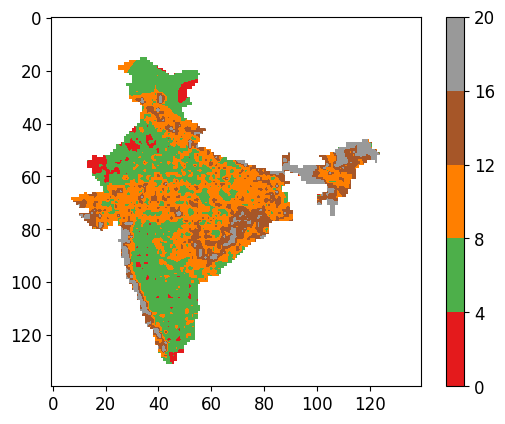

In [ ]:
import matplotlib.pyplot as plt  # Import pyplot for plotting
import numpy as np  # Import numpy for array handling
import matplotlib as mpl  # Import matplotlib

# Assuming mask and MAUNetLight_KR_loc_rmse_Test are already defined arrays of size 140x140
m = np.empty((140, 140))  # Initialize the array to hold the mapped values

# Populate the array `m` based on `mask` and `MAUNetLight_KR_loc_rmse_Test`
for i in range(140):
    for j in range(140):
        if mask[i][j] == 1:
            m[i][j] = np.nan  # Use numpy's NaN for missing values
        else:
            m[i][j] = MAUNetD_loc_rmse_Test[i][j]

# Define the colormap and normalization
cmap = mpl.colormaps['Set1']  # Corrected the colormap access syntax
bounds = [0,4,8,12,16,20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the image on the axis
img = ax.imshow(m, cmap=cmap, norm=norm)

# Add the colorbar using the ScalarMappable from the plotted image
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical")

# Set font sizes for axis ticks and colorbar
ax.tick_params(labelsize=12)  # Set axis tick font size
cbar.ax.tick_params(labelsize=12)  # Set colorbar tick font size

plt.show()  # Display the plot


#MAUNetLight Plot

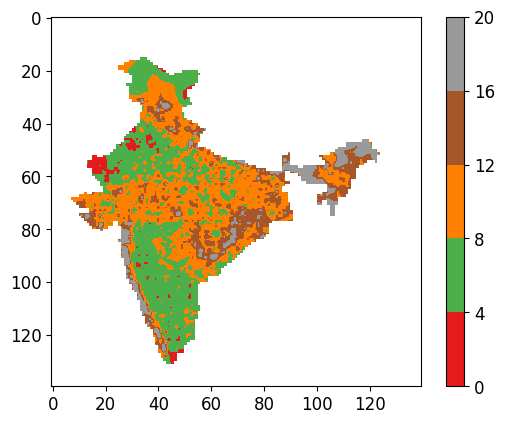

In [ ]:
import matplotlib.pyplot as plt  # Import pyplot for plotting
import numpy as np  # Import numpy for array handling
import matplotlib as mpl  # Import matplotlib

# Assuming mask and MAUNetLight_KR_loc_rmse_Test are already defined arrays of size 140x140
m = np.empty((140, 140))  # Initialize the array to hold the mapped values

# Populate the array `m` based on `mask` and `MAUNetLight_KR_loc_rmse_Test`
for i in range(140):
    for j in range(140):
        if mask[i][j] == 1:
            m[i][j] = np.nan  # Use numpy's NaN for missing values
        else:
            m[i][j] = MAUNetLight_KR_loc_rmse_Test[i][j]

# Define the colormap and normalization
cmap = mpl.colormaps['Set1']  # Corrected the colormap access syntax
bounds = [0,4,8,12,16,20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the image on the axis
img = ax.imshow(m, cmap=cmap, norm=norm)

# Add the colorbar using the ScalarMappable from the plotted image
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="vertical")

# Set font sizes for axis ticks and colorbar
ax.tick_params(labelsize=12)  # Set axis tick font size
cbar.ax.tick_params(labelsize=12)  # Set colorbar tick font size

plt.show()  # Display the plot
